In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [3]:
df = pd.read_csv(
    "SampleSuperstore_cleaned.csv", encoding='latin1',
    parse_dates=["order_date", "ship_date"]
)

In [4]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub-category   9994 n

In [7]:
#Total Sales (KPI)
total_sales = df['sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


Business Insights:

The company generated over $2.29 million in sales, indicating a strong sales volume during the analysis period.

In [8]:
# Total Profit
total_profit = df['profit'].sum()
print('Total Profit:',total_profit)

Total Profit: 286397.0217


In [9]:
#no.of orders
total_orders = df['order_id'].unique()
print('Total Orders:',len(total_orders))

Total Orders: 5009


In [10]:
#no.of customers
total_customers = df['customer_id'].unique()
print('Total Customers:',len(total_customers))

Total Customers: 793


In [11]:
#average sales per order
avg_sales_per_order = df['sales'].mean()
print('Average Sales per Order:', avg_sales_per_order)

Average Sales per Order: 229.85800083049833


In [12]:
#product category that generates the highest sales
category_sales = df.groupby('category')['sales'].sum()
print('product category that generates highest sales:',category_sales)

product category that generates highest sales: category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64


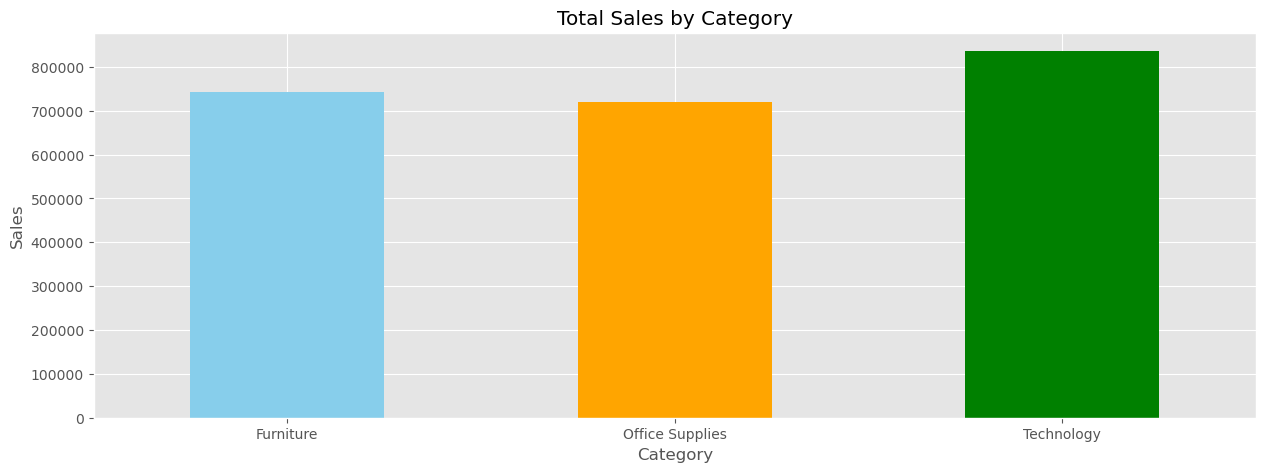

In [13]:
#create visualization for sales by category
plt.figure(figsize=(15,5))

category_sales.plot(
    kind="bar",
    color=["skyblue","orange","green"]
)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

Observations:

The Technology category generated the highest sales among all categories, indicating strong customer demand compared to Furniture and Office Supplies.

Business Insights:

Since Technology contributes the highest revenue, the company should prioritize inventory availability, marketing campaigns, and premium product launches in this category to maximize future sales.

In [14]:
#product category that generates highest profits
category_profit = df.groupby('category')['profit'].sum()
print('product category that generates highest profits:',category_profit)

product category that generates highest profits: category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: profit, dtype: float64


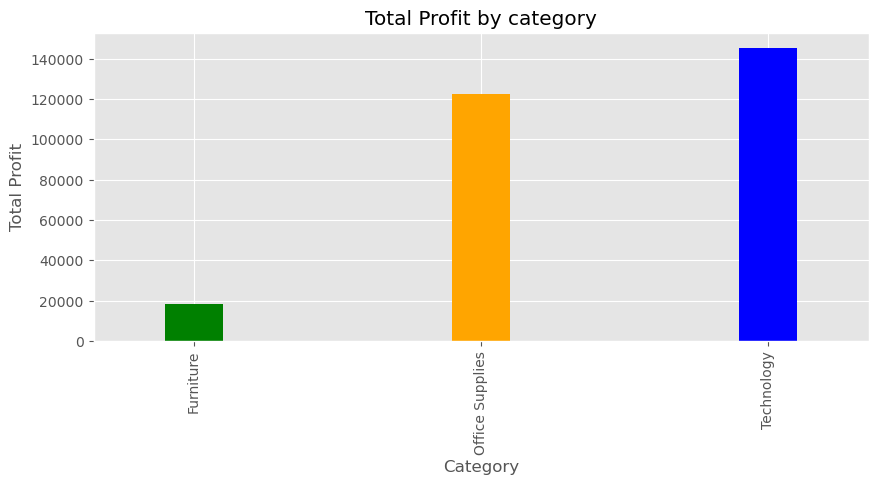

In [15]:
# creating visualization for profit by category
plt.figure(figsize=(10,4))

category_profit.plot(
    kind="bar",width=0.2,color=["green","orange","blue"]
)

plt.title("Total Profit by category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

Observations:

The Technology category generated the highest total profit, while Furniture generated the lowest profit among all categories.

Business Insights:

Although Furniture contributes significant sales, its profitability is lower than the other categories. The company should review pricing, discounts, and operational costs for Furniture products while continuing to invest in Technology, which delivers the highest profit

In [16]:
#region that generates highest sales
region_sales=df.groupby('region')['sales'].sum().sort_values(ascending=True)
print('Sales by region:',region_sales)

Sales by region: region
South      391721.9050
Central    501239.8908
East       678781.2400
West       725457.8245
Name: sales, dtype: float64


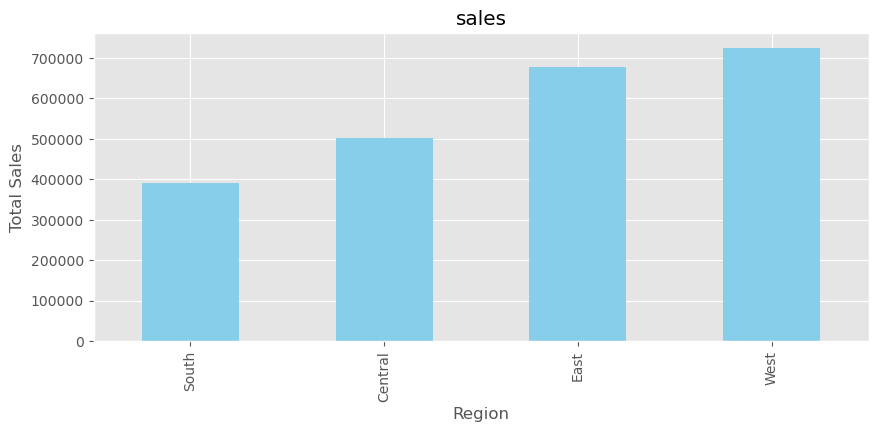

In [17]:
#creating visualization for sales by region
plt.figure(figsize=(10,4))
region_sales.plot(kind="bar", color="skyblue")
plt.title("sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

Observations:

The West region generated the highest sales, followed by East, Central, and South

Business Insights:

The West region is the company's strongest revenue contributor. The company should continue investing in this region while analyzing why the South region is underperforming.

Monthly Sales Trend

In [21]:
#extracting month and year from order_date
df['month']=df['order_date'].dt.month_name()
df['year']=df['order_date'].dt.year

In [22]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,month,year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2015


In [ ]:
#arranging months in order wise
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

In [28]:
df["month"] = pd.Categorical(
    df["month"],
    categories=month_order,
    ordered=True
)

In [29]:
#highest sales by month
sales_by_month=df.groupby('month')['sales'].sum()
print('Sales by month:',sales_by_month)

Sales by month: month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: sales, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\543186694.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_month=df.groupby('month')['sales'].sum()


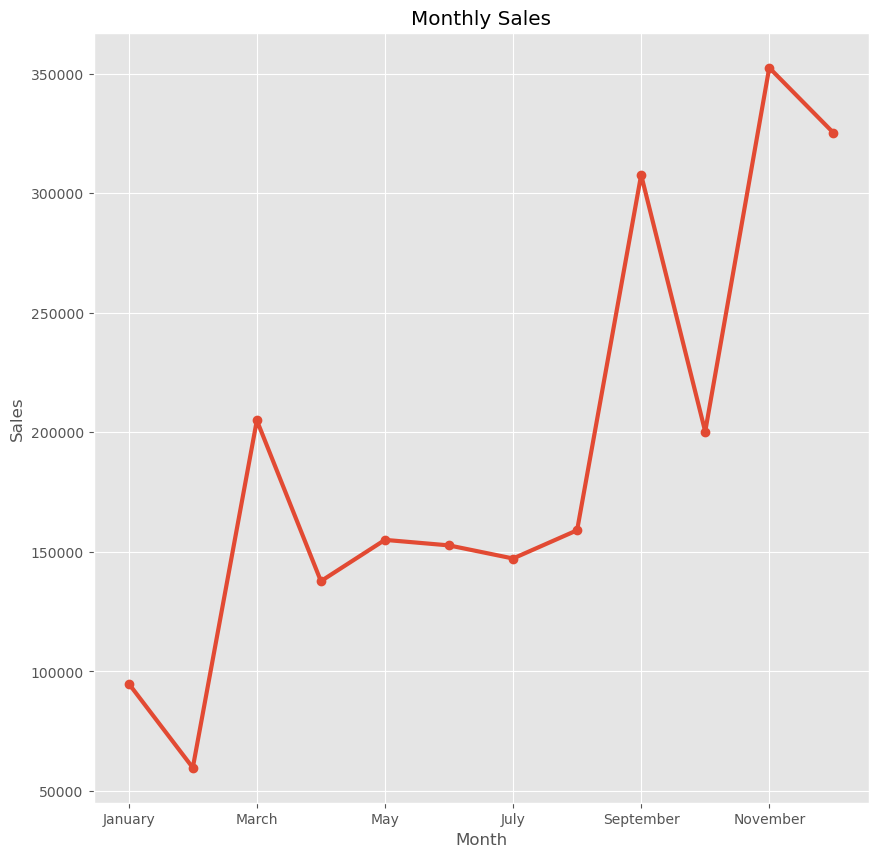

In [35]:
#creating the line chart for sales by month
plt.figure(figsize=(10,10))
sales_by_month.plot(kind='line',marker='o',linewidth=3)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


Observations:

Sales reached their highest levels during November and December, while February recorded comparatively lower sales.

Business Insights:

Sales peak during the year-end months, likely due to holiday shopping and seasonal promotions. The company should ensure adequate inventory and marketing campaigns during this period.

In [36]:
#highest sales by year
sales_by_year=df.groupby('year')['sales'].sum()
print('Sales by year:',sales_by_year)

Sales by year: year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: sales, dtype: float64


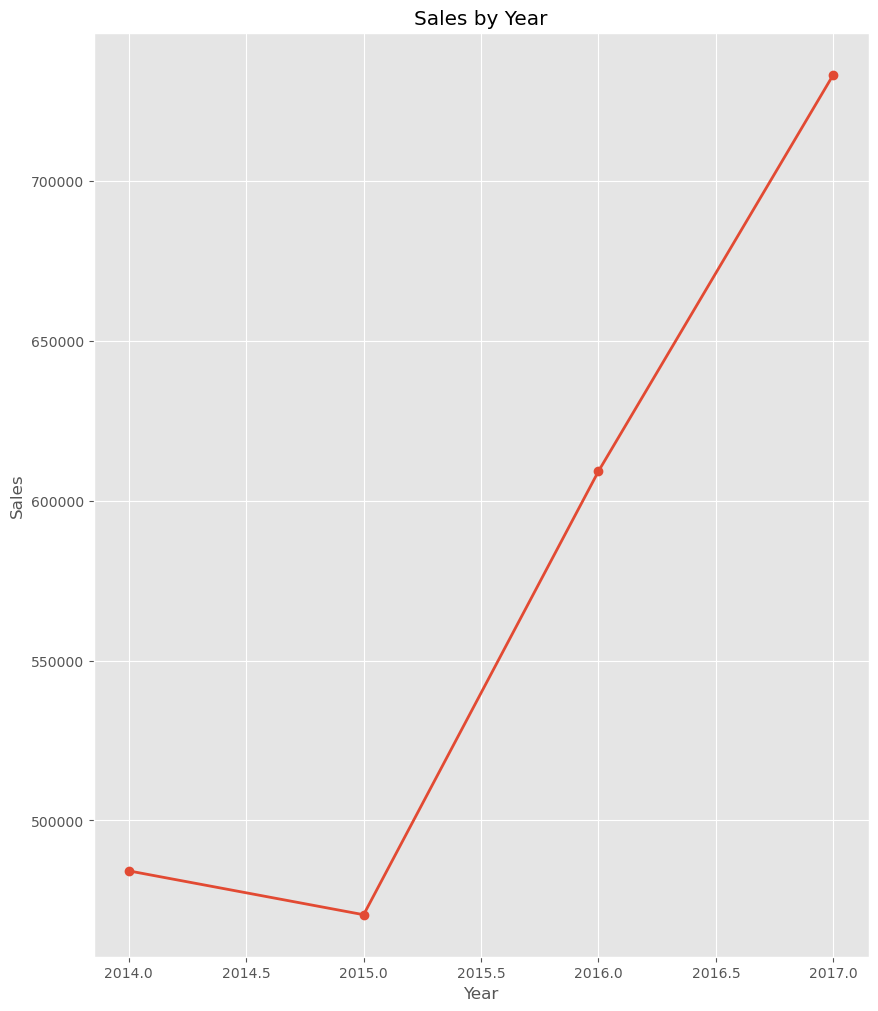

In [40]:
#creating visualization for sales by year
plt.figure(figsize=(10,12))
sales_by_year.plot(kind='line',marker='o',linewidth=2)
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Sales by Year')
plt.show()

Observations:

Sales reached their highest levels during the year between 2016 to 2017, while previous years showed lower sales.